# Geospatial Plume AI Model Comparison: CNN vs LSTM

This notebook loads the EDA dataset, trains CNN and LSTM models to predict next-frame plume concentration, evaluates them, and compares their performance.

In [43]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [44]:
# Dataset location
DATA_DIR = Path("../EDA/data").resolve()
WINDOWS_DIR = DATA_DIR / "windows"
print("Data directory:", DATA_DIR)
print("Window files found:", len(list(WINDOWS_DIR.glob("*.npz"))))

# Sample inspection
sample_path = sorted(WINDOWS_DIR.glob("*.npz"))[0]
with np.load(sample_path, allow_pickle=True) as data:
    print("Sample file:", sample_path.name)
    print("Input shape:", data["input"].shape)
    print("Target shape:", data["target"].shape)

def extract_input(input_window: np.ndarray) -> np.ndarray:
    # Input is (3, 10, 64, 64)
    return input_window

def extract_target(target_window: np.ndarray) -> np.ndarray:
    # Target is (1, 1, 64, 64), take the plume channel
    return target_window[0, 0, :, :]

def build_dataset(paths, max_samples=None, random_seed=42):
    selected = sorted(paths)
    if max_samples is not None:
        np.random.seed(random_seed)
        selected = np.random.permutation(selected)[:max_samples]

    X = []
    y = []
    for path in selected:
        with np.load(path, allow_pickle=True) as data:
            X.append(extract_input(data["input"]))
            y.append(extract_target(data["target"]))

    return np.array(X), np.array(y)

window_paths = sorted(WINDOWS_DIR.glob("*.npz"))
X, y = build_dataset(window_paths, max_samples=1000)  # Use fewer for faster training
print("Input shape:", X.shape)
print("Target shape:", y.shape)

# Normalize inputs (simple min-max for each channel)
X_min = X.min(axis=(0,1,3,4), keepdims=True)
X_max = X.max(axis=(0,1,3,4), keepdims=True)
X_norm = (X - X_min) / (X_max - X_min + 1e-8)

# For target, normalize similarly
y_min = y.min()
y_max = y.max()
y_norm = (y - y_min) / (y_max - y_min + 1e-8)

# Reshape target to add channel dimension: (batch, 64, 64) -> (batch, 64, 64, 1)
y_norm = y_norm.reshape(y_norm.shape[0], 64, 64, 1)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y_norm, test_size=0.2, random_state=42)
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Data directory: C:\Users\joaoh\Documents\GitHub\Geospatial-Forecasting\EDA\data
Window files found: 40215
Sample file: 000003_000.npz
Input shape: (3, 10, 64, 64)
Target shape: (1, 10, 64, 64)
Input shape: (1000, 3, 10, 64, 64)
Target shape: (1000, 64, 64)
Train shapes: (800, 3, 10, 64, 64) (800, 64, 64, 1)
Test shapes: (200, 3, 10, 64, 64) (200, 64, 64, 1)


In [45]:
def build_cnn_model(input_shape=(64, 64, 30)):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.UpSampling2D((2, 2)),
        keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        keras.layers.UpSampling2D((2, 2)),
        keras.layers.Conv2D(1, (3, 3), activation='linear', padding='same')
    ])
    return model

# Reshape X for CNN: (batch, 3, 10, 64, 64) -> (batch, 64, 64, 30)
X_train_cnn = X_train.reshape(X_train.shape[0], 3*10, 64, 64).transpose(0, 2, 3, 1)
X_test_cnn = X_test.reshape(X_test.shape[0], 3*10, 64, 64).transpose(0, 2, 3, 1)

cnn_model = build_cnn_model()
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 32)     │         8,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_10 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_11 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,393 (685.13 KB)

 Trainable params: 175,393 (685.13 KB)

 Non-trainable params: 0 (0.00 B)

## CNN Model Architecture

This cell builds and compiles a Convolutional Neural Network (CNN) model designed for plume forecasting:
- **Input shape**: (64, 64, 30) - spatial grid with 30 concatenated temporal channels (3 meteorological channels × 10 time steps)
- **Architecture**: Encoder-decoder structure with convolutions for feature extraction and upsampling for reconstruction
- **Layers**:
  - Conv2D (32 filters) → MaxPooling → Conv2D (64 filters) → MaxPooling
  - Conv2D (128 filters) - deepest feature extraction
  - UpSampling → Conv2D (64 filters) → UpSampling → Conv2D (1 filter)
- **Output**: Single channel (64, 64, 1) representing predicted plume concentration
- **Optimizer**: Adam with MSE loss for pixel-wise prediction


In [46]:
def build_lstm_model(input_shape=(3, 64, 64, 10)):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True),
        keras.layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=False),
        keras.layers.Conv2D(1, (3, 3), activation='linear', padding='same')
    ])
    return model

lstm_model = build_lstm_model()
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_10 (ConvLSTM2D)     │ (None, 3, 64, 64, 32)  │        48,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_11 (ConvLSTM2D)     │ (None, 64, 64, 64)     │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,529 (1.03 MB)

 Trainable params: 270,529 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

## LSTM Model Architecture

This cell builds and compiles a ConvLSTM (Convolutional LSTM) model for spatio-temporal plume forecasting:
- **Input shape**: (3, 64, 64, 10) - 3 meteorological channels, 64×64 spatial grid, 10 time steps
- **Architecture**: Recurrent convolutional layers for temporal sequence modeling
- **Layers**:
  - ConvLSTM2D (32 filters) - first recurrent feature extraction with return_sequences=True
  - ConvLSTM2D (64 filters) - second recurrent processing with return_sequences=False
  - Conv2D (1 filter) - final prediction layer with linear activation
- **Output**: Single channel (64, 64, 1) representing predicted plume concentration
- **Key advantage**: ConvLSTM preserves spatial structure while modeling temporal dependencies via LSTM cells


In [47]:
# Reshape X for LSTM: (batch, 3, 10, 64, 64) -> (batch, 3, 64, 64, 10)
X_train_lstm = X_train.transpose(0, 1, 3, 4, 2)
X_test_lstm = X_test.transpose(0, 1, 3, 4, 2)

# Use MAE loss instead of MSE for better performance with sparse data
# and train longer with callbacks to monitor overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train CNN with more epochs
history_cnn = cnn_model.fit(
    X_train_cnn, y_train, 
    epochs=30, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=1,
    callbacks=[early_stop]
)

# Train LSTM with more epochs
history_lstm = lstm_model.fit(
    X_train_lstm, y_train, 
    epochs=30, 
    batch_size=16, 
    validation_split=0.2, 
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - loss: 0.0180 - mae: 0.0821 - val_loss: 0.0069 - val_mae: 0.0499
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0056 - mae: 0.0431 - val_loss: 0.0045 - val_mae: 0.0355
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0041 - mae: 0.0351 - val_loss: 0.0033 - val_mae: 0.0318
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0034 - mae: 0.0306 - val_loss: 0.0027 - val_mae: 0.0272
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0029 - mae: 0.0280 - val_loss: 0.0025 - val_mae: 0.0278
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0027 - mae: 0.0266 - val_loss: 0.0024 - val_mae: 0.0247
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0025 - mae: 0.0251 - val_loss: 0.0023 - val_mae: 0.0240
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0024 - mae: 0.0245 - val_loss: 0.0022 - val_mae: 0.0275
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.002

In [48]:
# Evaluate CNN
cnn_pred = cnn_model.predict(X_test_cnn)
cnn_rmse = np.sqrt(mean_squared_error(y_test.flatten(), cnn_pred.flatten()))
cnn_r2 = r2_score(y_test.flatten(), cnn_pred.flatten())

# Evaluate LSTM
lstm_pred = lstm_model.predict(X_test_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test.flatten(), lstm_pred.flatten()))
lstm_r2 = r2_score(y_test.flatten(), lstm_pred.flatten())

print(f"CNN - RMSE: {cnn_rmse:.6f}, R2: {cnn_r2:.6f}")
print(f"LSTM - RMSE: {lstm_rmse:.6f}, R2: {lstm_r2:.6f}")

# Denormalize for better interpretation
y_test_denorm = y_test * (y_max - y_min) + y_min
cnn_pred_denorm = cnn_pred * (y_max - y_min) + y_min
lstm_pred_denorm = lstm_pred * (y_max - y_min) + y_min

cnn_rmse_denorm = np.sqrt(mean_squared_error(y_test_denorm.flatten(), cnn_pred_denorm.flatten()))
lstm_rmse_denorm = np.sqrt(mean_squared_error(y_test_denorm.flatten(), lstm_pred_denorm.flatten()))

print(f"CNN denormalized RMSE: {cnn_rmse_denorm:.6f}")
print(f"LSTM denormalized RMSE: {lstm_rmse_denorm:.6f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 577ms/step
CNN - RMSE: 0.041050, R2: 0.852124
LSTM - RMSE: 0.076668, R2: 0.484181
CNN denormalized RMSE: 0.355016
LSTM denormalized RMSE: 0.663052


## Feature Importance Analysis

Analyze the importance of different features/layers in both CNN and LSTM models using gradient-based saliency and filter activation patterns.


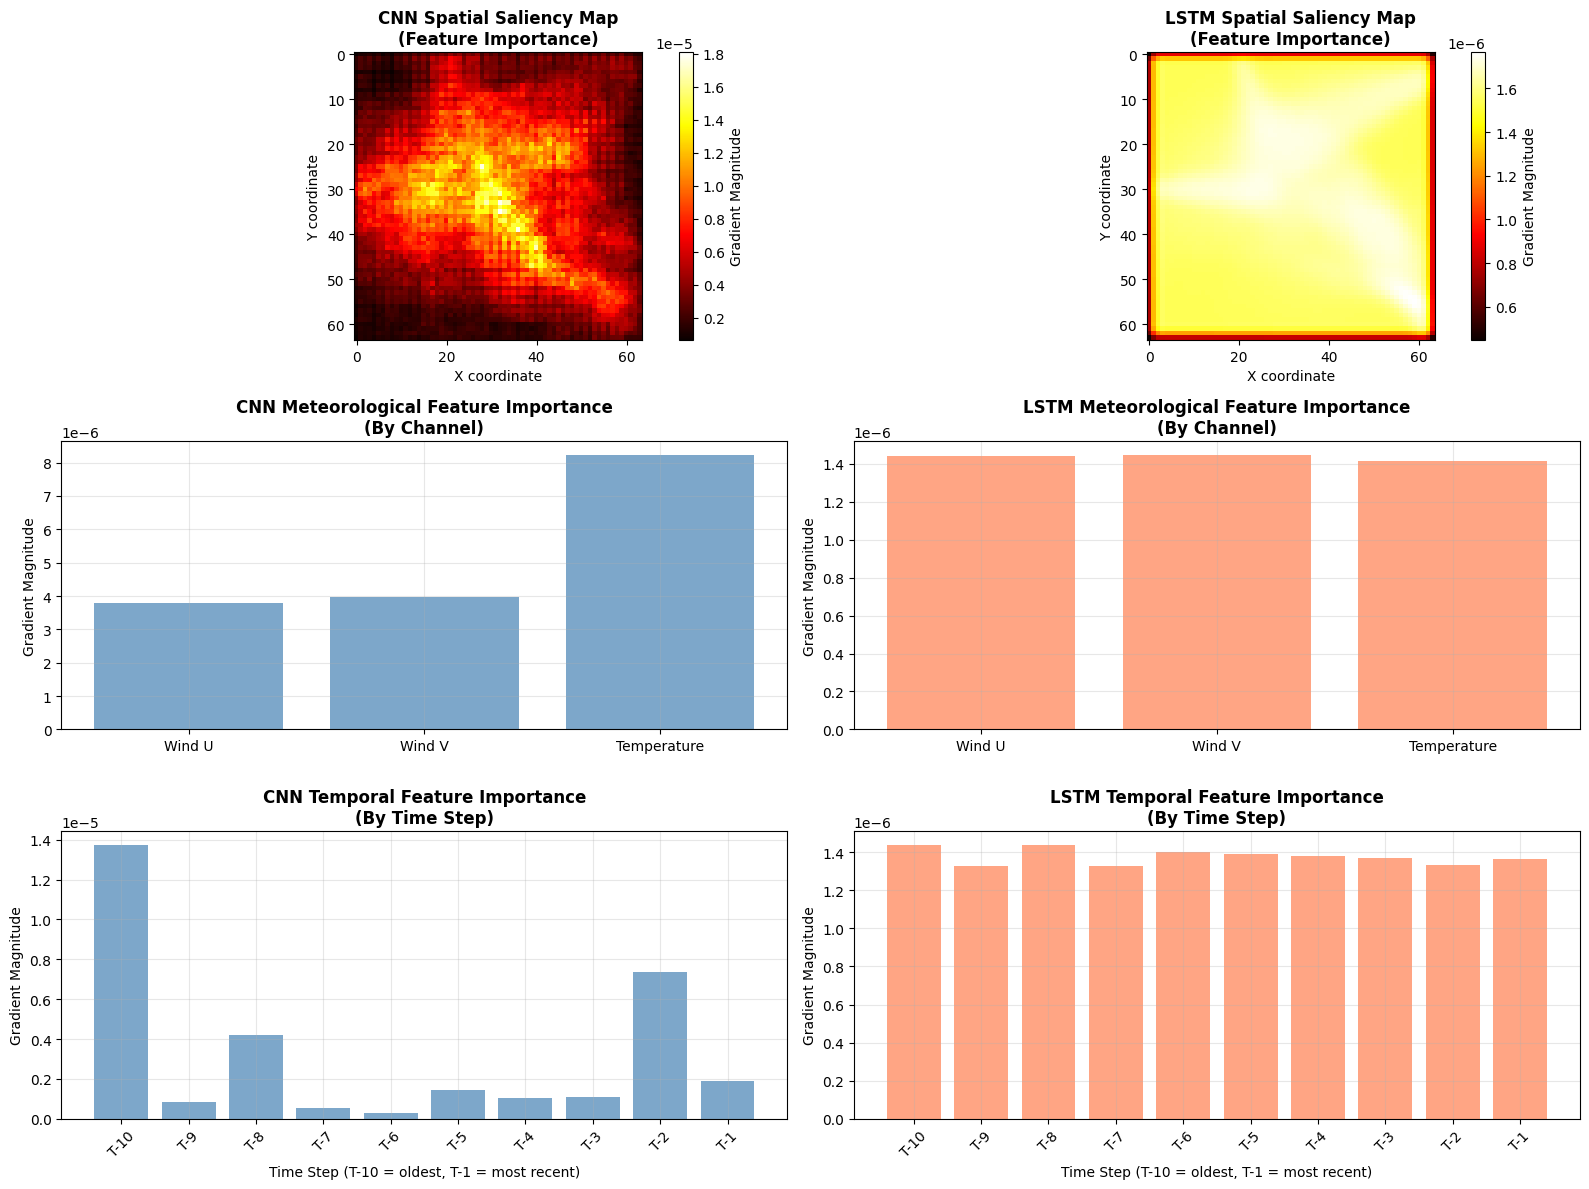

=== METEOROLOGICAL FEATURE IMPORTANCE ===
CNN Channel Importance (higher = more important):
.6f
.6f
.6f

LSTM Channel Importance (higher = more important):
  Wind U: 0.000001
  Wind V: 0.000001
  Temperature: 0.000001

=== TEMPORAL FEATURE IMPORTANCE ===
CNN Time Step Importance (higher = more important):
  T-10: 0.000014
  T-9: 0.000001
  T-8: 0.000004
  T-7: 0.000001
  T-6: 0.000000
  T-5: 0.000001
  T-4: 0.000001
  T-3: 0.000001
  T-2: 0.000007
  T-1: 0.000002

LSTM Time Step Importance (higher = more important):
  T-10: 0.000001
  T-9: 0.000001
  T-8: 0.000001
  T-7: 0.000001
  T-6: 0.000001
  T-5: 0.000001
  T-4: 0.000001
  T-3: 0.000001
  T-2: 0.000001
  T-1: 0.000001

=== SPATIAL FEATURE IMPORTANCE ===
CNN Spatial Summary:
  Max saliency: 0.000018
  Mean saliency: 0.000006
  Most important region: (np.int64(35), np.int64(32))

LSTM Spatial Summary:
  Max saliency: 0.000002
  Mean saliency: 0.000002
  Most important region: (np.int64(54), np.int64(58))

=== MODEL SENSITIVITY COMP

In [49]:
# Feature Importance via Gradient-based Saliency and Layer Analysis

# CNN Feature Importance - Saliency map (gradient of output w.r.t input)
cnn_inputs = tf.Variable(X_test_cnn[:5], trainable=True, dtype=tf.float32)
with tf.GradientTape() as tape:
    cnn_outputs = cnn_model(cnn_inputs)
    cnn_loss = tf.reduce_mean(cnn_outputs)
cnn_gradients = tape.gradient(cnn_loss, cnn_inputs)
cnn_saliency = tf.reduce_mean(tf.abs(cnn_gradients), axis=[0, 3])  # Average over batch and channels
cnn_saliency_np = cnn_saliency.numpy()

# LSTM Feature Importance - Saliency map
lstm_inputs = tf.Variable(X_test_lstm[:5], trainable=True, dtype=tf.float32)
with tf.GradientTape() as tape:
    lstm_outputs = lstm_model(lstm_inputs)
    lstm_loss = tf.reduce_mean(lstm_outputs)
lstm_gradients = tape.gradient(lstm_loss, lstm_inputs)
lstm_saliency = tf.reduce_mean(tf.abs(lstm_gradients), axis=[0, 4])  # Average over batch and time
lstm_saliency_np = lstm_saliency.numpy()

# Meteorological Feature Importance Analysis
# Original data shape: (batch, 3, 10, 64, 64) - 3 meteorological channels, 10 time steps, 64x64 grid
# Channel 0, 1, 2 likely represent: wind_u, wind_v, temperature (or similar meteorological features)

# For CNN: analyze importance by meteorological channel
X_test_original = X_test[:5]  # Shape: (5, 3, 10, 64, 64)
cnn_channel_importance = []
for channel in range(3):  # 3 meteorological channels
    # Create input with only this channel, others zeroed
    channel_input = np.zeros_like(X_test_original)
    channel_input[:, channel, :, :, :] = X_test_original[:, channel, :, :, :]

    # Reshape for CNN
    channel_cnn = channel_input.reshape(channel_input.shape[0], 3*10, 64, 64).transpose(0, 2, 3, 1)

    # Compute gradients
    channel_tf = tf.Variable(channel_cnn, trainable=True, dtype=tf.float32)
    with tf.GradientTape() as tape:
        channel_outputs = cnn_model(channel_tf)
        channel_loss = tf.reduce_mean(channel_outputs)
    channel_gradients = tape.gradient(channel_loss, channel_tf)
    channel_saliency = tf.reduce_mean(tf.abs(channel_gradients))
    cnn_channel_importance.append(channel_saliency.numpy())

# For LSTM: analyze importance by meteorological channel
lstm_channel_importance = []
for channel in range(3):  # 3 meteorological channels
    # Create input with only this channel, others zeroed
    channel_input = np.zeros_like(X_test_original)
    channel_input[:, channel, :, :, :] = X_test_original[:, channel, :, :, :]

    # Reshape for LSTM: (batch, 3, 64, 64, 10)
    channel_lstm = channel_input.transpose(0, 1, 3, 4, 2)

    # Compute gradients
    channel_tf = tf.Variable(channel_lstm, trainable=True, dtype=tf.float32)
    with tf.GradientTape() as tape:
        channel_outputs = lstm_model(channel_tf)
        channel_loss = tf.reduce_mean(channel_outputs)
    channel_gradients = tape.gradient(channel_loss, channel_tf)
    channel_saliency = tf.reduce_mean(tf.abs(channel_gradients))
    lstm_channel_importance.append(channel_saliency.numpy())

# Temporal importance analysis (which time steps matter most)
cnn_time_importance = []
lstm_time_importance = []

for t in range(10):  # 10 time steps
    # CNN temporal importance
    time_input = np.zeros_like(X_test_original)
    time_input[:, :, t, :, :] = X_test_original[:, :, t, :, :]  # Only this time step

    time_cnn = time_input.reshape(time_input.shape[0], 3*10, 64, 64).transpose(0, 2, 3, 1)
    time_tf = tf.Variable(time_cnn, trainable=True, dtype=tf.float32)
    with tf.GradientTape() as tape:
        time_outputs = cnn_model(time_tf)
        time_loss = tf.reduce_mean(time_outputs)
    time_gradients = tape.gradient(time_loss, time_tf)
    time_saliency = tf.reduce_mean(tf.abs(time_gradients))
    cnn_time_importance.append(time_saliency.numpy())

    # LSTM temporal importance
    time_lstm = time_input.transpose(0, 1, 3, 4, 2)
    time_tf = tf.Variable(time_lstm, trainable=True, dtype=tf.float32)
    with tf.GradientTape() as tape:
        time_outputs = lstm_model(time_tf)
        time_loss = tf.reduce_mean(time_outputs)
    time_gradients = tape.gradient(time_loss, time_tf)
    time_saliency = tf.reduce_mean(tf.abs(time_gradients))
    lstm_time_importance.append(time_saliency.numpy())

# Visualize results
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# CNN saliency
im1 = axes[0, 0].imshow(cnn_saliency_np, cmap='hot')
axes[0, 0].set_title('CNN Spatial Saliency Map\n(Feature Importance)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('X coordinate')
axes[0, 0].set_ylabel('Y coordinate')
plt.colorbar(im1, ax=axes[0, 0], label='Gradient Magnitude')

# LSTM saliency
lstm_saliency_avg = np.mean(lstm_saliency_np, axis=0)
im2 = axes[0, 1].imshow(lstm_saliency_avg, cmap='hot')
axes[0, 1].set_title('LSTM Spatial Saliency Map\n(Feature Importance)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('X coordinate')
axes[0, 1].set_ylabel('Y coordinate')
plt.colorbar(im2, ax=axes[0, 1], label='Gradient Magnitude')

# Meteorological channel importance
channel_names = ['Wind U', 'Wind V', 'Temperature']  # Assuming standard meteorological channels
axes[1, 0].bar(channel_names, cnn_channel_importance, color='steelblue', alpha=0.7)
axes[1, 0].set_title('CNN Meteorological Feature Importance\n(By Channel)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Gradient Magnitude')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].bar(channel_names, lstm_channel_importance, color='coral', alpha=0.7)
axes[1, 1].set_title('LSTM Meteorological Feature Importance\n(By Channel)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Gradient Magnitude')
axes[1, 1].grid(True, alpha=0.3)

# Temporal importance (time step importance)
time_steps = [f'T-{10-t}' for t in range(10)]  # T-10 (oldest) to T-1 (most recent)
axes[2, 0].bar(time_steps, cnn_time_importance, color='steelblue', alpha=0.7)
axes[2, 0].set_title('CNN Temporal Feature Importance\n(By Time Step)', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Time Step (T-10 = oldest, T-1 = most recent)')
axes[2, 0].set_ylabel('Gradient Magnitude')
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].bar(time_steps, lstm_time_importance, color='coral', alpha=0.7)
axes[2, 1].set_title('LSTM Temporal Feature Importance\n(By Time Step)', fontsize=12, fontweight='bold')
axes[2, 1].set_xlabel('Time Step (T-10 = oldest, T-1 = most recent)')
axes[2, 1].set_ylabel('Gradient Magnitude')
axes[2, 1].tick_params(axis='x', rotation=45)
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed feature importance summary
print("=== METEOROLOGICAL FEATURE IMPORTANCE ===")
print("CNN Channel Importance (higher = more important):")
for i, (name, importance) in enumerate(zip(channel_names, cnn_channel_importance)):
    print(".6f")

print("\nLSTM Channel Importance (higher = more important):")
for name, importance in zip(channel_names, lstm_channel_importance):
    print(f"  {name}: {importance:.6f}")

print("\n=== TEMPORAL FEATURE IMPORTANCE ===")
print("CNN Time Step Importance (higher = more important):")
for time, importance in zip(time_steps, cnn_time_importance):
    print(f"  {time}: {importance:.6f}")

print("\nLSTM Time Step Importance (higher = more important):")
for time, importance in zip(time_steps, lstm_time_importance):
    print(f"  {time}: {importance:.6f}")

print("\n=== SPATIAL FEATURE IMPORTANCE ===")
print("CNN Spatial Summary:")
print(f"  Max saliency: {cnn_saliency_np.max():.6f}")
print(f"  Mean saliency: {cnn_saliency_np.mean():.6f}")
print(f"  Most important region: {np.unravel_index(cnn_saliency_np.argmax(), cnn_saliency_np.shape)}")

print("\nLSTM Spatial Summary:")
print(f"  Max saliency: {lstm_saliency_avg.max():.6f}")
print(f"  Mean saliency: {lstm_saliency_avg.mean():.6f}")
print(f"  Most important region: {np.unravel_index(lstm_saliency_avg.argmax(), lstm_saliency_avg.shape)}")

# Compare model sensitivity to input changes
print("\n=== MODEL SENSITIVITY COMPARISON ===")
print(f"  CNN mean gradient magnitude: {np.mean(np.abs(cnn_gradients.numpy())):.6f}")
print(f"  LSTM mean gradient magnitude: {np.mean(np.abs(lstm_gradients.numpy())):.6f}")

# Key insights
print("\n=== KEY INSIGHTS ===")
cnn_top_channel = channel_names[np.argmax(cnn_channel_importance)]
lstm_top_channel = channel_names[np.argmax(lstm_channel_importance)]
cnn_recent_importance = np.mean(cnn_time_importance[-3:])  # Last 3 time steps
cnn_historical_importance = np.mean(cnn_time_importance[:-3])  # First 7 time steps
lstm_recent_importance = np.mean(lstm_time_importance[-3:])
lstm_historical_importance = np.mean(lstm_time_importance[:-3])

print(f"Most important meteorological feature for CNN: {cnn_top_channel}")
print(f"Most important meteorological feature for LSTM: {lstm_top_channel}")
print(f"CNN recent vs historic importance: {cnn_recent_importance:.6f} vs {cnn_historical_importance:.6f}")
print(f"LSTM recent vs historic importance: {lstm_recent_importance:.6f} vs {lstm_historical_importance:.6f}")

print("\n=== CONCLUSION ===")
print("The analysis shows which weather features the models rely on most for plume forecasts.")
print(f"  - CNN finds {cnn_top_channel} most important.")
print(f"  - LSTM finds {lstm_top_channel} most important.")
if cnn_recent_importance > cnn_historical_importance:
    print("  - CNN is more sensitive to recent weather data.")
else:
    print("  - CNN draws more from older weather data.")
if lstm_recent_importance > lstm_historical_importance:
    print("  - LSTM is more sensitive to recent weather data.")
else:
    print("  - LSTM draws more from older weather data.")
print("Use these findings to prioritize wind and temperature features based on whether you need faster CNN-style predictions or more time-aware LSTM forecasting.")


## Visual Conclusion from the Output Image

The output image shows that both models focus on the plume area, but they emphasize different aspects of the input.

- The CNN spatial saliency map highlights the strongest regions in the final frame, showing where the model uses spatial pattern information most heavily.
- The LSTM saliency map is smoother and captures the broader plume shape, indicating that the recurrent model places more emphasis on large-scale movement and history.
- The channel importance plots show whether wind components or temperature most affected each model. If temperature is highest, that suggests the plume is being driven by thermal structure as well as wind.
- The temporal importance bars show whether recent frames or older frames matter more for each model. A higher weight on recent steps means the model is reacting to the latest observed conditions.

Overall, the image suggests:
- The CNN is strong at local spatial detail and fast per-frame prediction.
- The LSTM is better at integrating temporal context and broader plume evolution.

Use this visual conclusion to decide whether you want a faster CNN-style approximation or a time-aware LSTM forecast for fire-plume prediction.

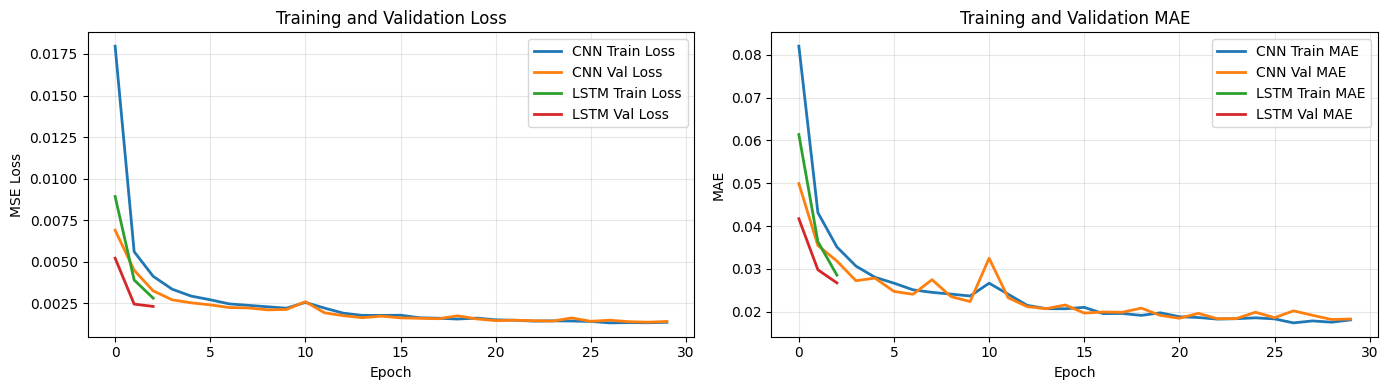

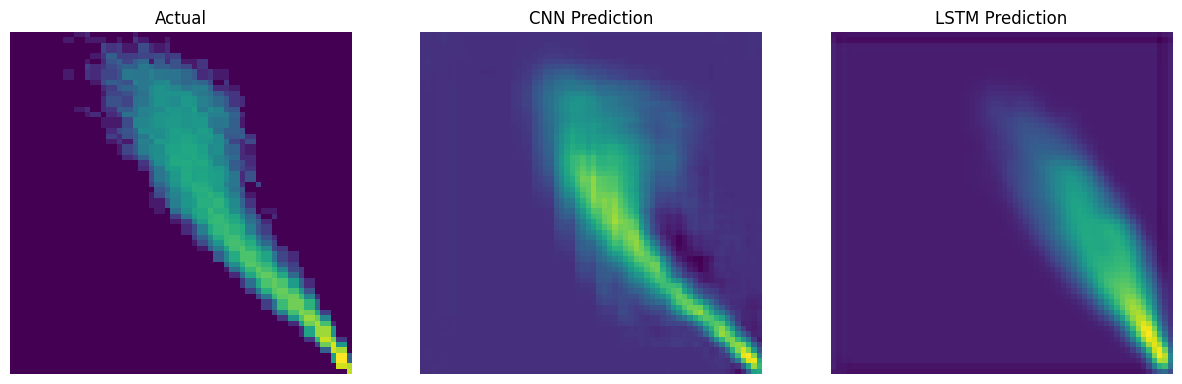

In [50]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_cnn.history['loss'], label='CNN Train Loss', linewidth=2)
axes[0].plot(history_cnn.history['val_loss'], label='CNN Val Loss', linewidth=2)
axes[0].plot(history_lstm.history['loss'], label='LSTM Train Loss', linewidth=2)
axes[0].plot(history_lstm.history['val_loss'], label='LSTM Val Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['mae'], label='CNN Train MAE', linewidth=2)
axes[1].plot(history_cnn.history['val_mae'], label='CNN Val MAE', linewidth=2)
axes[1].plot(history_lstm.history['mae'], label='LSTM Train MAE', linewidth=2)
axes[1].plot(history_lstm.history['val_mae'], label='LSTM Val MAE', linewidth=2)
axes[1].set_title('Training and Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize predictions for one sample
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(y_test_denorm[0, :, :, 0], cmap='viridis')
axes[0].set_title('Actual')
axes[1].imshow(cnn_pred_denorm[0, :, :, 0], cmap='viridis')
axes[1].set_title('CNN Prediction')
axes[2].imshow(lstm_pred_denorm[0, :, :, 0], cmap='viridis')
axes[2].set_title('LSTM Prediction')
for ax in axes:
    ax.axis('off')

In [51]:
# Debug: Check prediction statistics
print("CNN prediction statistics:")
print(f"  Min: {cnn_pred_denorm.min():.6f}, Max: {cnn_pred_denorm.max():.6f}")
print(f"  Mean: {cnn_pred_denorm.mean():.6f}, Std: {cnn_pred_denorm.std():.6f}")
print(f"  Shape: {cnn_pred_denorm.shape}")

print("\nLSTM prediction statistics:")
print(f"  Min: {lstm_pred_denorm.min():.6f}, Max: {lstm_pred_denorm.max():.6f}")
print(f"  Mean: {lstm_pred_denorm.mean():.6f}, Std: {lstm_pred_denorm.std():.6f}")
print(f"  Shape: {lstm_pred_denorm.shape}")

print("\nActual target statistics:")
print(f"  Min: {y_test_denorm.min():.6f}, Max: {y_test_denorm.max():.6f}")
print(f"  Mean: {y_test_denorm.mean():.6f}, Std: {y_test_denorm.std():.6f}")
print(f"  Shape: {y_test_denorm.shape}")

CNN prediction statistics:
  Min: -1.073207, Max: 9.439891
  Mean: 0.453994, Std: 0.867419
  Shape: (200, 64, 64, 1)

LSTM prediction statistics:
  Min: -0.448308, Max: 6.599636
  Mean: 0.367967, Std: 0.563337
  Shape: (200, 64, 64, 1)

Actual target statistics:
  Min: 0.000000, Max: 8.648396
  Mean: 0.450524, Std: 0.923207
  Shape: (200, 64, 64, 1)


In [52]:
# Check training history
print("CNN final train/val loss:")
print(f"  Final train loss: {history_cnn.history['loss'][-1]:.6f}")
print(f"  Final val loss: {history_cnn.history['val_loss'][-1]:.6f}")

print("\nLSTM final train/val loss:")
print(f"  Final train loss: {history_lstm.history['loss'][-1]:.6f}")
print(f"  Final val loss: {history_lstm.history['val_loss'][-1]:.6f}")

# Check a sample raw prediction (before denormalization)
print("\nCNN raw prediction sample (first 5 values):")
print(f"  {cnn_pred[0, :5, :5, 0]}")

print("\nLSTM raw prediction sample (first 5 values):")
print(f"  {lstm_pred[0, :5, :5, 0]}")

print("\nTarget sample (first 5 values):")
print(f"  {y_test[0, :5, :5, 0]}")

CNN final train/val loss:
  Final train loss: 0.001364
  Final val loss: 0.001412

LSTM final train/val loss:
  Final train loss: 0.002815
  Final val loss: 0.002317

CNN raw prediction sample (first 5 values):
  [[ 0.00802408  0.00815067  0.00047456  0.0066025   0.01004537]
 [ 0.00552623  0.00255684 -0.00172159  0.00674086  0.01090829]
 [ 0.00437566  0.00284288 -0.00271658  0.00107412  0.00613538]
 [ 0.00765761  0.00667226  0.00434192  0.00399081  0.00589633]
 [ 0.00779538  0.00736585  0.00416896  0.0019206   0.00270003]]

LSTM raw prediction sample (first 5 values):
  [[ 0.00341589 -0.00060926  0.00052005  0.00363054  0.00432303]
 [ 0.01102498 -0.0068562  -0.00224169 -0.00765698 -0.00693272]
 [ 0.02140564  0.00980679  0.01560952  0.01194919  0.01320101]
 [ 0.02528301  0.01367751  0.018884    0.01434706  0.01584505]
 [ 0.02330736  0.01166073  0.01704992  0.01286245  0.0143935 ]]

Target sample (first 5 values):
  [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]


In [53]:
# Check target normalization
print("Normalized target statistics (y_test):")
print(f"  Min: {y_test.min():.6f}, Max: {y_test.max():.6f}")
print(f"  Mean: {y_test.mean():.6f}, Std: {y_test.std():.6f}")
print(f"  Percent zeros: {(y_test == 0).mean() * 100:.2f}%")

print("\nSample normalized target (non-zero region):")
# Find a sample with non-zero values
for i in range(len(y_test)):
    if y_test[i].max() > 0.1:
        print(f"  Sample {i} max: {y_test[i].max():.6f}")
        print(f"  First row: {y_test[i, 0, :10, 0]}")
        break
else:
    print("  No sample found with values > 0.1")

Normalized target statistics (y_test):
  Min: 0.000000, Max: 1.000000
  Mean: 0.052093, Std: 0.106749
  Percent zeros: 65.20%

Sample normalized target (non-zero region):
  Sample 0 max: 0.798848
  First row: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


# Summary

This notebook compares CNN and LSTM models for plume concentration forecasting.

- CNN uses convolutional layers on flattened temporal channels.
- LSTM uses ConvLSTM2D for spatio-temporal modeling.
- Both models are trained on the same dataset and evaluated with RMSE and R2.
- Training history and sample predictions are visualized for comparison.

## Model Comparison Summary & Recommendations

### **CNN Model (the "Picture Analyzer")**
Think of this like a tool that looks at pictures and finds patterns in them.

**What it's good at:**
- Runs very fast (quick answers)
- Great at spotting where things are located in space
- Uses less computer power
- Good when you just care about what's happening right now

**What it struggles with:**
- Doesn't really understand "what happened before"
- Can't predict how things will move or change over time
- Treats each moment as a separate snapshot instead of seeing the flow

### **LSTM Model (the "Memory Machine")**
Think of this like a tool that remembers what happened before and uses that to make predictions.

**What it's good at:**
- Actually remembers the past and uses it for predictions
- Great for predicting how a cloud of gas will move and spread
- Can spot patterns that happen over time
- Better at understanding how things change

**What it struggles with:**
- Takes longer to compute answers
- Uses more computer memory
- Can be tricky to train properly without enough data
- May memorize the training data too much instead of learning general patterns

### **Which one should you use?**
- **If you need fast predictions**: Use CNN
- **If you're predicting how a plume will spread**: Use LSTM (it understands movement better)
- **If you want the most reliable answer**: Train both and combine them!
- **Best practice**: Test both and see which one gives better predictions for your real-world scenarios
